# Val/Test Divergence Curves

Plots per-epoch AUPRC on the synthetic val set vs the original test set for each model.

Generated by `anomaly_benchmark.py` → `divergence_curves.csv`.

**Interpreting the curves:**
- **Val (synthetic):** AUPRC on synthetic graph val nodes — what early stopping optimises.
- **Test (original):** AUPRC on original graph test nodes — the actual utility signal.
- The **divergence point** is where val keeps climbing while test plateaus or drops.
  A large gap indicates the synthetic graph does not faithfully capture the original's anomaly structure.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# --- Configure which run to analyse ---
GENERATOR      = 'bigg'
DATASET        = 'questions'
SYNTHETIC_NAME = 'blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.25_lnmdn8_lsf-4.0_loadsub_metis_K15_split0_n15'

# Resolve project root — works whether Jupyter is launched from root or scripts/benchmark/
_cwd = Path.cwd()
PROJ_ROOT   = _cwd if (_cwd / 'scripts').exists() else (_cwd / '../..').resolve()
RESULTS_DIR = PROJ_ROOT / 'results' / 'evaluate' / GENERATOR / DATASET / SYNTHETIC_NAME
CURVES_PATH = RESULTS_DIR / 'divergence_curves.csv'
EVAL_PATH   = RESULTS_DIR / 'evaluation_results.csv'
OUT_DIR     = RESULTS_DIR / 'divergence_plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)

df      = pd.read_csv(CURVES_PATH)
eval_df = pd.read_csv(EVAL_PATH)
print(f'Curves: {len(df)} rows')
print(f'  sources:  {df.source.unique().tolist()}')
print(f'  models:   {df.model.unique().tolist()}')
print(f'Eval:   {len(eval_df)} rows, models: {eval_df.model.unique().tolist()}')

# Models that have per-epoch curves vs models plotted as final-AUPRC reference lines
CURVE_MODELS   = sorted(df.model.unique().tolist())
ALL_MODELS     = sorted(eval_df.model.unique().tolist())
NOCURVE_MODELS = [m for m in ALL_MODELS if m not in CURVE_MODELS]
print(f'Curve models:               {CURVE_MODELS}')
print(f'No-curve (final-AUPRC ref): {NOCURVE_MODELS}')
df.head()

Curves: 854 rows
  sources:  ['original', 'synthetic-graph', 'real-subsampled-graph']
  models:   ['GCN', 'GIN', 'GraphSAGE']
Eval:   15 rows, models: ['GCN', 'GIN', 'GraphSAGE', 'XGBGraph', 'XGBoost']
Curve models:               ['GCN', 'GIN', 'GraphSAGE']
No-curve (final-AUPRC ref): ['XGBGraph', 'XGBoost']


,source,dataset,model,epoch,val_auprc_mean,val_auprc_std,test_auprc_mean,test_auprc_std
0,original,questions,GCN,0,0.026499,0.0,0.029002,0.0
1,original,questions,GCN,1,0.057736,0.0,0.059940,0.0
2,original,questions,GCN,2,0.058352,0.0,0.065237,0.0
3,original,questions,GCN,3,0.060956,0.0,0.068079,0.0
4,original,questions,GCN,4,0.064524,0.0,0.072948,0.0


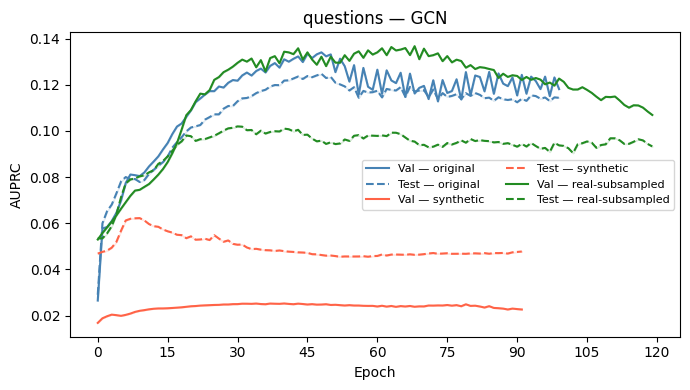

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/questions/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.25_lnmdn8_lsf-4.0_loadsub_metis_K15_split0_n15/divergence_plots/questions_GCN.png


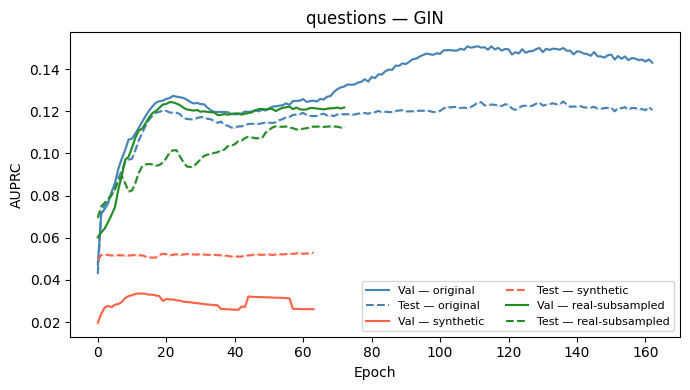

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/questions/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.25_lnmdn8_lsf-4.0_loadsub_metis_K15_split0_n15/divergence_plots/questions_GIN.png


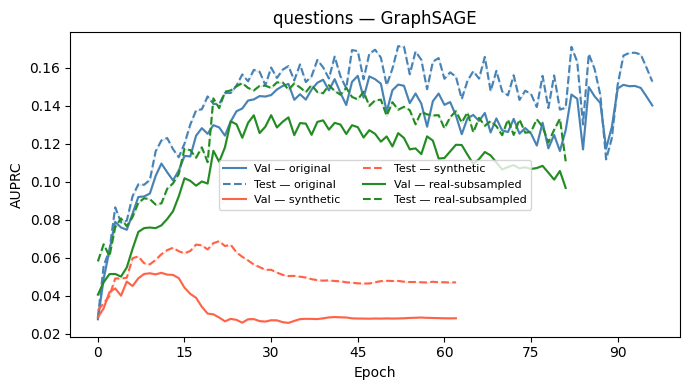

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/questions/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.25_lnmdn8_lsf-4.0_loadsub_metis_K15_split0_n15/divergence_plots/questions_GraphSAGE.png


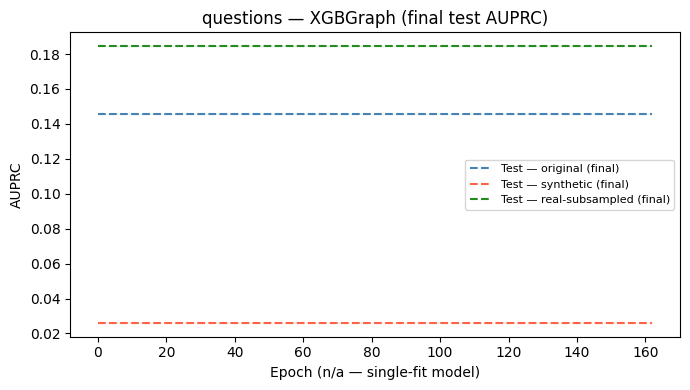

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/questions/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.25_lnmdn8_lsf-4.0_loadsub_metis_K15_split0_n15/divergence_plots/questions_XGBGraph.png


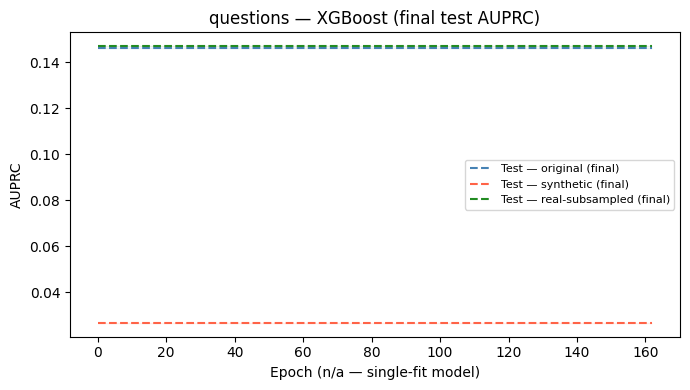

Saved /home/eirik/progg/master/SynBench/results/evaluate/bigg/questions/blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.25_lnmdn8_lsf-4.0_loadsub_metis_K15_split0_n15/divergence_plots/questions_XGBoost.png


In [5]:
SOURCE_COLORS = {
    'original':              'steelblue',
    'synthetic-graph':       'tomato',
    'real-subsampled-graph': 'forestgreen',
}
SOURCE_LABELS = {
    'original':              'original',
    'synthetic-graph':       'synthetic',
    'real-subsampled-graph': 'real-subsampled',
}


def _plot_curve_model(ax, grp):
    """Plot val (solid) + test (dashed) curves for each source on a single axis."""
    for src, color in SOURCE_COLORS.items():
        sgrp = grp[grp['source'] == src]
        if sgrp.empty:
            continue
        label = SOURCE_LABELS[src]
        ax.plot(sgrp['epoch'], sgrp['val_auprc_mean'],
                label=f'Val — {label}', color=color, linestyle='-')
        ax.fill_between(sgrp['epoch'],
                        sgrp['val_auprc_mean'] - sgrp['val_auprc_std'],
                        sgrp['val_auprc_mean'] + sgrp['val_auprc_std'],
                        alpha=0.15, color=color)
        ax.plot(sgrp['epoch'], sgrp['test_auprc_mean'],
                label=f'Test — {label}', color=color, linestyle='--')
        ax.fill_between(sgrp['epoch'],
                        sgrp['test_auprc_mean'] - sgrp['test_auprc_std'],
                        sgrp['test_auprc_mean'] + sgrp['test_auprc_std'],
                        alpha=0.15, color=color)


def _plot_nocurve_model(ax, dataset, model, x_max):
    """XGB models: only final test AUPRC is saved. Plot horizontal test reference lines."""
    rows = eval_df[(eval_df['dataset'] == dataset) & (eval_df['model'] == model)]
    for src, color in SOURCE_COLORS.items():
        r = rows[rows['source'] == src]
        if r.empty:
            continue
        m = float(r['AUPRC_mean'].iloc[0])
        s = float(r['AUPRC_std'].iloc[0])
        label = SOURCE_LABELS[src]
        ax.hlines(m, 0, x_max, color=color, linestyle='--',
                  label=f'Test — {label} (final)')
        ax.fill_between([0, x_max], m - s, m + s, alpha=0.12, color=color)


# Use the curve-models' epoch range as the x-axis span for horizontal reference plots
x_max = int(df['epoch'].max()) if not df.empty else 100

# 1. Models with per-epoch curves (GCN/GIN/GraphSAGE)
for (dataset, model), grp in df.groupby(['dataset', 'model']):
    fig, ax = plt.subplots(figsize=(7, 4))
    _plot_curve_model(ax, grp)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUPRC')
    ax.set_title(f'{dataset} — {model}')
    ax.legend(fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()

    out_path = OUT_DIR / f'{dataset}_{model}.png'
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close(fig)
    print(f'Saved {out_path}')

# 2. Models without curves (XGBGraph/XGBoost) — final test AUPRC as horizontal reference
for model in NOCURVE_MODELS:
    for dataset in eval_df['dataset'].unique():
        if eval_df[(eval_df['dataset'] == dataset) & (eval_df['model'] == model)].empty:
            continue
        fig, ax = plt.subplots(figsize=(7, 4))
        _plot_nocurve_model(ax, dataset, model, x_max)
        ax.set_xlabel('Epoch (n/a — single-fit model)')
        ax.set_ylabel('AUPRC')
        ax.set_title(f'{dataset} — {model} (final test AUPRC)')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        plt.tight_layout()

        out_path = OUT_DIR / f'{dataset}_{model}.png'
        plt.savefig(out_path, dpi=150)
        plt.show()
        plt.close(fig)
        print(f'Saved {out_path}')

In [6]:
# Divergence summary: at the epoch early stopping picks (peak val), what is test?
# val_test_gap > 0 means val overestimates true test performance at that checkpoint.
# XGB rows have NaN val/gap — only the final test AUPRC is recorded for single-fit models.
rows = []

# Curve models: best val epoch + val/test at that epoch
for (dataset, model, source), sgrp in df.groupby(['dataset', 'model', 'source']):
    best_row     = sgrp.iloc[sgrp['val_auprc_mean'].values.argmax()]
    val_at_best  = best_row['val_auprc_mean']
    test_at_best = best_row['test_auprc_mean']
    rows.append({
        'dataset': dataset, 'model': model, 'source': source,
        'best_val_epoch': int(best_row['epoch']),
        'val_auprc':    val_at_best,
        'test_auprc':   test_at_best,
        'val_test_gap': val_at_best - test_at_best,
    })

# No-curve models: only final test AUPRC available; val and gap not tracked
for _, r in eval_df.iterrows():
    if r['model'] in CURVE_MODELS:
        continue
    rows.append({
        'dataset': r['dataset'], 'model': r['model'], 'source': r['source'],
        'best_val_epoch': pd.NA,
        'val_auprc':      pd.NA,
        'test_auprc':     r['AUPRC_mean'],
        'val_test_gap':   pd.NA,
    })

summary = pd.DataFrame(rows).sort_values(['dataset', 'model', 'source'])
print('Summary — val_test_gap: how much val overestimates true test performance at early-stopping epoch')
print('NaN entries are XGB models — only final test AUPRC was recorded; val curve not tracked.')
summary.round(4)

Summary — val_test_gap: how much val overestimates true test performance at early-stopping epoch
NaN entries are XGB models — only final test AUPRC was recorded; val curve not tracked.


,dataset,model,source,best_val_epoch,val_auprc,test_auprc,val_test_gap
0,questions,GCN,original,48,0.13407,0.1248,0.009313
1,questions,GCN,real-subsampled-graph,68,0.136742,0.0954,0.041338
2,questions,GCN,synthetic-graph,40,0.025231,0.0479,-0.022666
3,questions,GIN,original,111,0.15092,0.1243,0.026663
4,questions,GIN,real-subsampled-graph,21,0.12441,0.1006,0.023789
5,questions,GIN,synthetic-graph,12,0.033595,0.0517,-0.018069
6,questions,GraphSAGE,original,45,0.155737,0.1688,-0.013017
7,questions,GraphSAGE,real-subsampled-graph,30,0.135,0.1494,-0.014373
8,questions,GraphSAGE,synthetic-graph,11,0.051997,0.0618,-0.009793
9,questions,XGBGraph,original,<NA>,<NA>,0.1456,<NA>
